## Question 1: Intensity Transformations

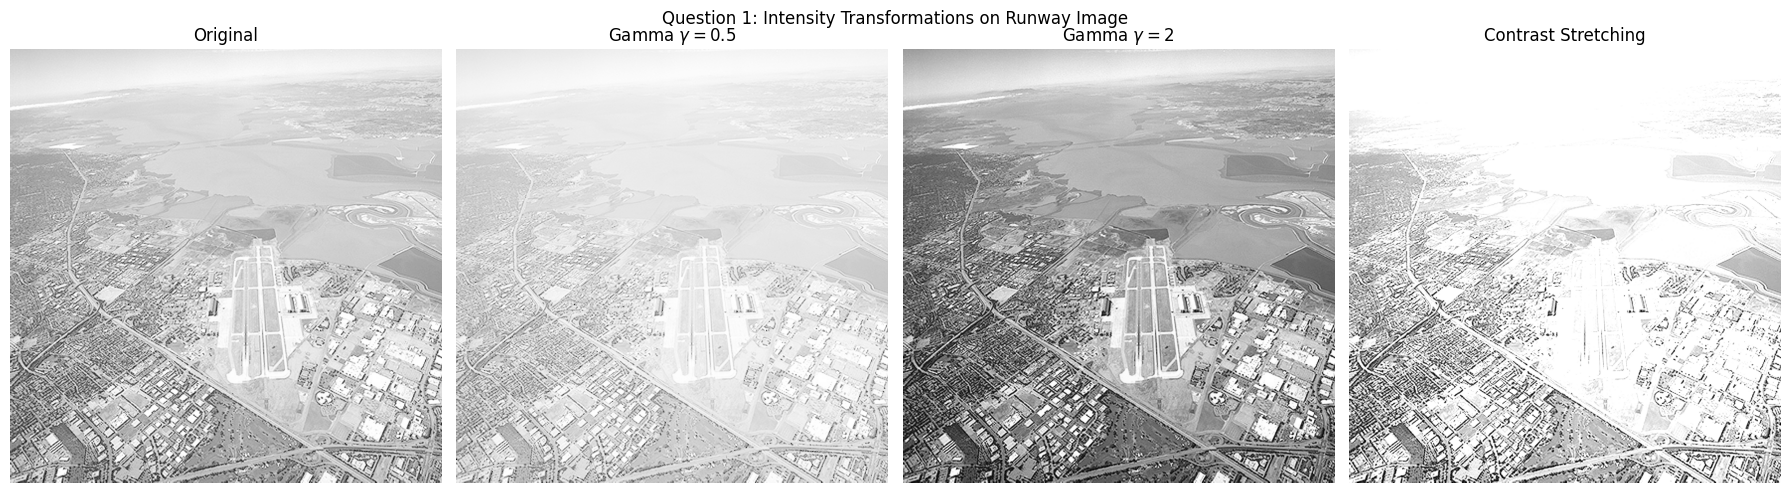

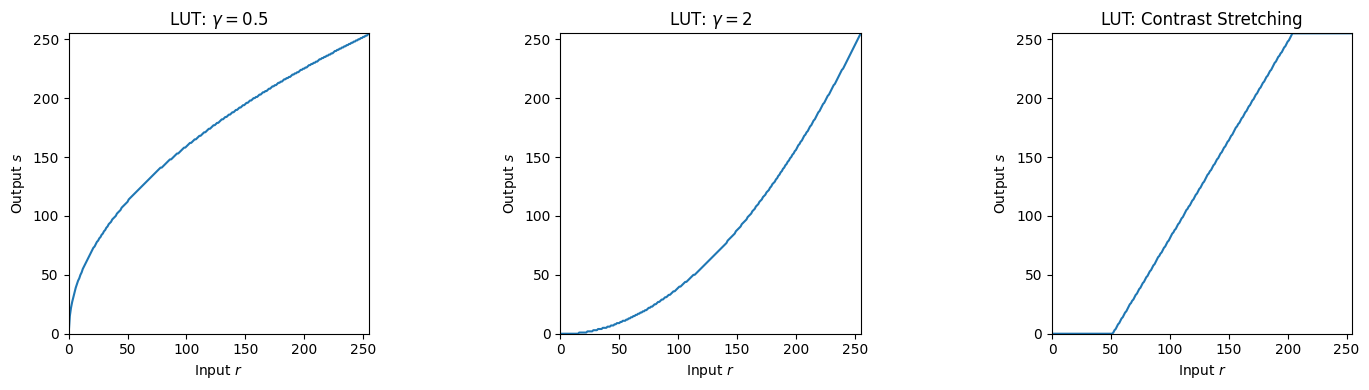

In [6]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load the runway image
img = cv.imread('E:/ML/Images/Fig0309(a)(washed_out_aerial_image).tif', cv.IMREAD_GRAYSCALE)
assert img is not None, 'Could not load runway image'

#(a) Gamma correction γ = 0.5 
gamma_05 = 0.5
table_05 = np.array([(i / 255.0) ** gamma_05 * 255.0
                     for i in np.arange(0, 256)]).astype('uint8')
img_gamma_05 = cv.LUT(img, table_05)

#(b) Gamma correction γ = 2 
gamma_2 = 2
table_2 = np.array([(i / 255.0) ** gamma_2 * 255.0
                    for i in np.arange(0, 256)]).astype('uint8')
img_gamma_2 = cv.LUT(img, table_2)

#(c) Contrast Stretching 
r1, r2 = 0.2, 0.8
contrast_table = np.zeros(256, dtype='uint8')
for i in range(256):
    r = i / 255.0
    if r < r1:
        s = 0.0
    elif r <= r2:
        s = (r - r1) / (r2 - r1)
    else:
        s = 1.0
    contrast_table[i] = np.clip(s * 255, 0, 255)

img_contrast = cv.LUT(img, contrast_table)

# Display all results
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
titles = ['Original', r'Gamma $\gamma=0.5$', r'Gamma $\gamma=2$', 'Contrast Stretching']
images = [img, img_gamma_05, img_gamma_2, img_contrast]

for ax, title, image in zip(axes, titles, images):
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis('off')

plt.suptitle('Question 1: Intensity Transformations on Runway Image')
plt.tight_layout()
plt.savefig('q1_intensity_transforms.png', dpi=150)
plt.show()

# Plot the transform functions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(table_05)
axes[0].set_title(r'LUT: $\gamma = 0.5$')
axes[1].plot(table_2)
axes[1].set_title(r'LUT: $\gamma = 2$')
axes[2].plot(contrast_table)
axes[2].set_title('LUT: Contrast Stretching')
for ax in axes:
    ax.set_xlabel(r'Input $r$')
    ax.set_ylabel(r'Output $s$')
    ax.set_xlim(0, 255)
    ax.set_ylim(0, 255)
    ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('q1_lut_curves.png', dpi=150)
plt.show()

## Question 2: Gamma Correction in L\*a\*b\* Color Space

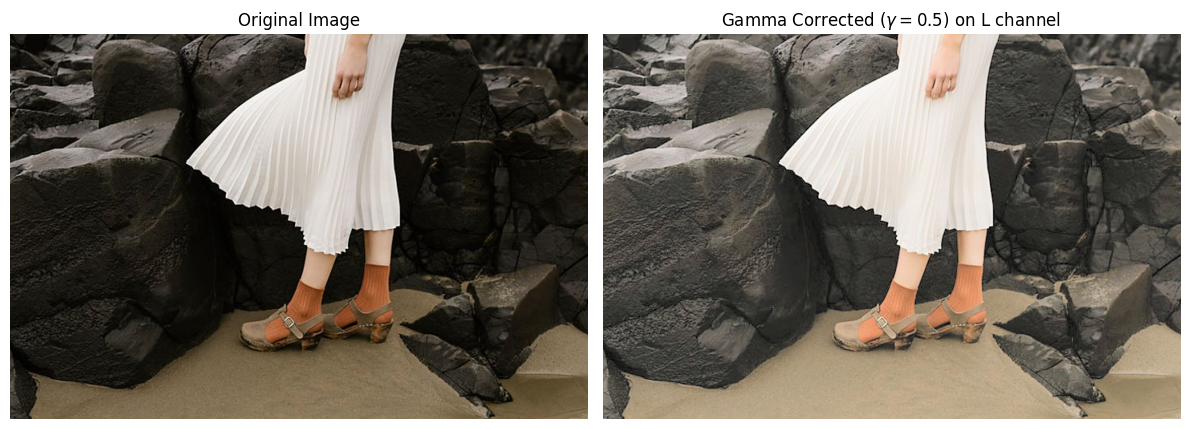

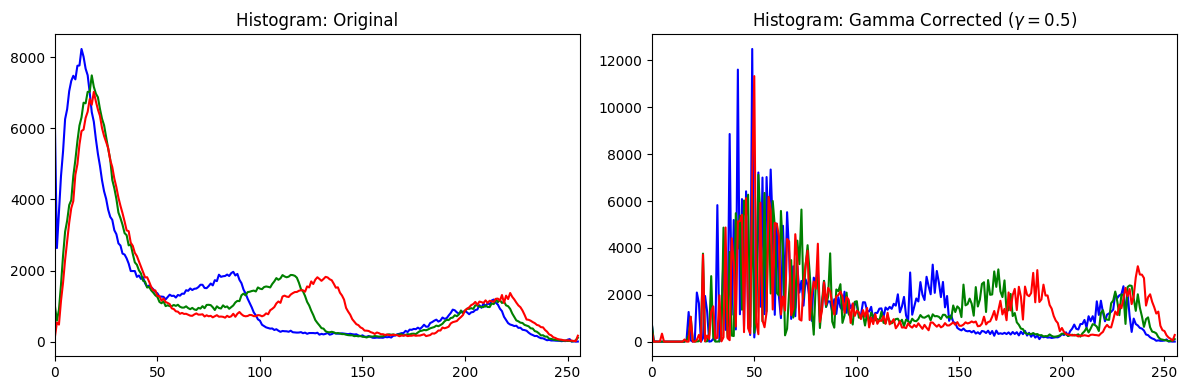

Gamma value used: 0.5
Gamma < 1 brightens the image by expanding dark L values.


In [7]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load the color image (Fig. 2 - the outdoor/person image)
img_bgr = cv.imread('E:/ML/Images/highlights_and_shadows.jpg', cv.IMREAD_COLOR)
assert img_bgr is not None, 'Could not load image for Q2'

# Convert BGR -> Lab 
img_lab = cv.cvtColor(img_bgr, cv.COLOR_BGR2Lab)
L, a, b = cv.split(img_lab)

# Apply gamma correction to the L channel
# L is dark => gamma < 1 brightens; choose gamma = 0.5 to brighten
gamma = 0.5
table = np.array([(i / 255.0) ** gamma * 255.0
                  for i in np.arange(0, 256)]).astype('uint8')
L_corrected = cv.LUT(L, table)

# Merge back and convert to BGR
img_lab_corrected = cv.merge([L_corrected, a, b])
img_corrected_bgr = cv.cvtColor(img_lab_corrected, cv.COLOR_Lab2BGR)

# Convert for matplotlib display (RGB)
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
img_corrected_rgb = cv.cvtColor(img_corrected_bgr, cv.COLOR_BGR2RGB)

#Display images 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_rgb)
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(img_corrected_rgb)
axes[1].set_title(f'Gamma Corrected ($\\gamma = {gamma}$) on L channel')
axes[1].axis('off')
plt.tight_layout()
plt.savefig('q2_gamma_lab.png', dpi=150)
plt.show()

#(b) Histograms 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
color = ('b', 'g', 'r')
for i, c in enumerate(color):
    hist_orig = cv.calcHist([img_bgr], [i], None, [256], [0, 256])
    axes[0].plot(hist_orig, color=c)
axes[0].set_title('Histogram: Original')
axes[0].set_xlim([0, 256])

for i, c in enumerate(color):
    hist_corr = cv.calcHist([img_corrected_bgr], [i], None, [256], [0, 256])
    axes[1].plot(hist_corr, color=c)
axes[1].set_title(f'Histogram: Gamma Corrected ($\\gamma = {gamma}$)')
axes[1].set_xlim([0, 256])

plt.tight_layout()
plt.savefig('q2_histograms.png', dpi=150)
plt.show()

print(f'Gamma value used: {gamma}')
print('Gamma < 1 brightens the image by expanding dark L values.')

## Question 3: Custom Histogram Equalization

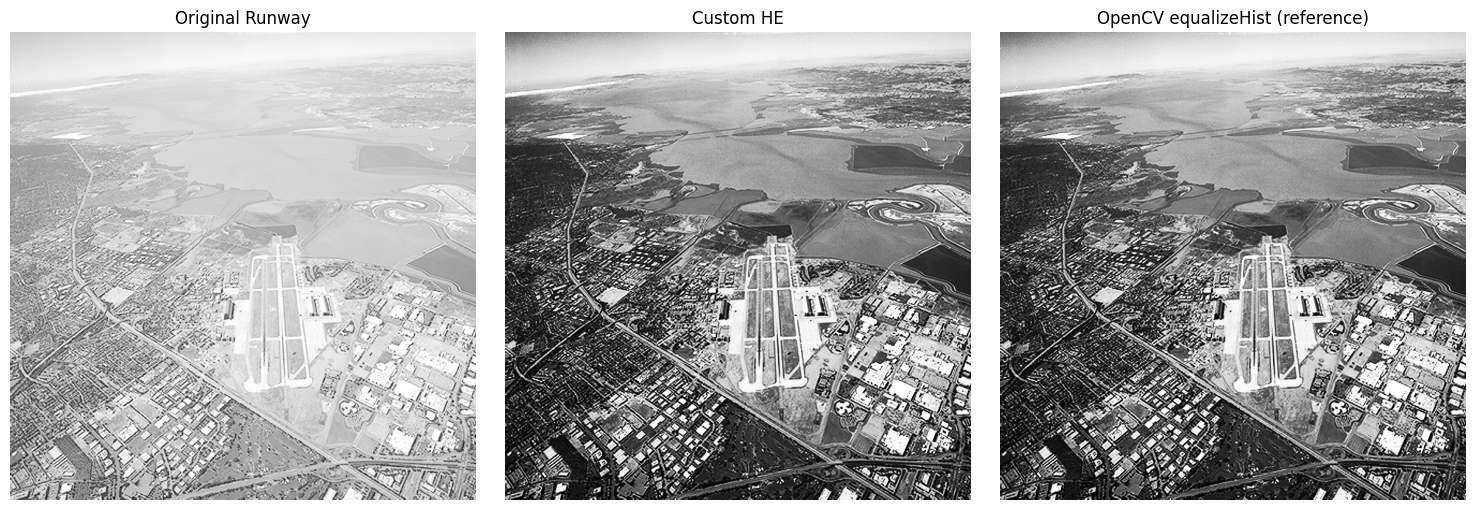

C:\Users\DELL\AppData\Local\Temp\ipykernel_19808\1604855106.py:49: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  ax.hist(image.flatten(), 256, [0, 256], color='r', alpha=0.5, label='Histogram')


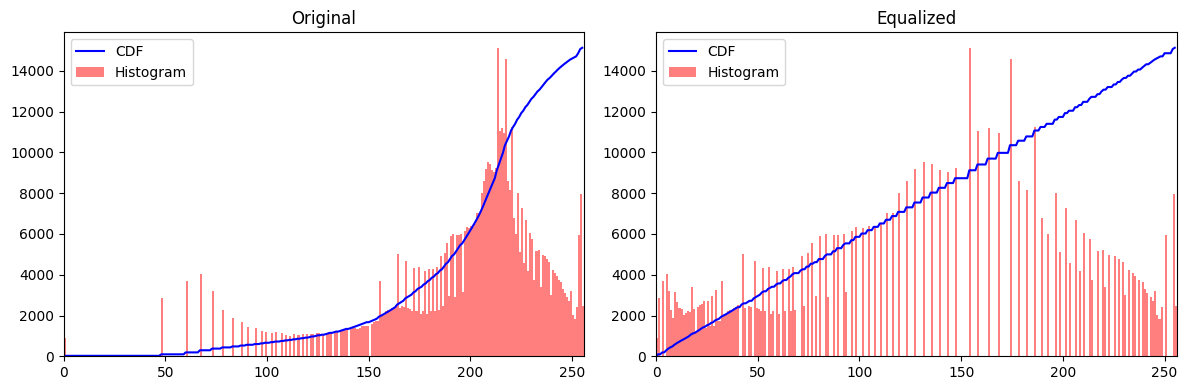

Max pixel difference vs OpenCV equalizeHist: 0


In [8]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def equalize_histogram(image):
    assert image.ndim == 2, 'Input must be a grayscale image'
    hist, _ = np.histogram(image.ravel(), bins=256, range=(0, 256))
    
    # CDF
    cdf = hist.cumsum()
    
    # Normalize: map to [0, 255]
    # Exclude zero-valued CDF bins 
    cdf_min = cdf[cdf > 0].min()
    total_pixels = image.size
    lut = np.round((cdf - cdf_min) / (total_pixels - cdf_min) * 255).astype('uint8')
    
    return lut[image]


runway = cv.imread('E:/ML/Images/Fig0309(a)(washed_out_aerial_image).tif', cv.IMREAD_GRAYSCALE)
assert runway is not None

runway_eq = equalize_histogram(runway)
runway_eq_cv = cv.equalizeHist(runway)  

#Display images 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(runway, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original Runway')
axes[0].axis('off')
axes[1].imshow(runway_eq, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Custom HE')
axes[1].axis('off')
axes[2].imshow(runway_eq_cv, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('OpenCV equalizeHist (reference)')
axes[2].axis('off')
plt.tight_layout()
plt.savefig('q3_histogram_equalization.png', dpi=150)
plt.show()

#Histograms & CDF
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, image, title in zip(axes, [runway, runway_eq], ['Original', 'Equalized']):
    hist, bins = np.histogram(image.ravel(), 256, [0, 256])
    cdf = hist.cumsum()
    cdf_norm = cdf * hist.max() / cdf.max()
    ax.plot(cdf_norm, color='b', label='CDF')
    ax.hist(image.flatten(), 256, [0, 256], color='r', alpha=0.5, label='Histogram')
    ax.set_title(title)
    ax.set_xlim([0, 256])
    ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('q3_histograms.png', dpi=150)
plt.show()

# Verify custom matches OpenCV
diff = np.abs(runway_eq.astype(int) - runway_eq_cv.astype(int))
print(f'Max pixel difference vs OpenCV equalizeHist: {diff.max()}')

## Question 4: Otsu Thresholding & Selective Histogram Equalization

Otsu threshold value: 99.0


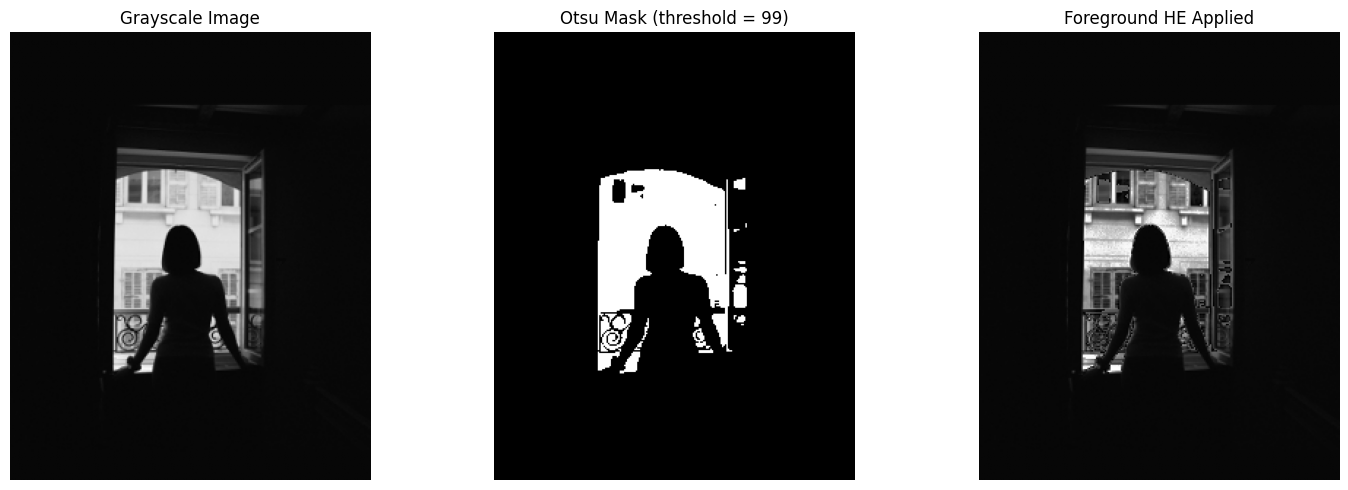

Hidden features revealed: Details in the room (walls, window frame, furniture) become visible after equalizing the darker foreground pixels.


In [9]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


img_bgr = cv.imread('E:/ML/Images/Window.png', cv.IMREAD_COLOR)
assert img_bgr is not None, 'Could not load woman_window image'
img_gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)

#(a) Otsu thresholding 
thresh_val, binary_mask = cv.threshold(
    img_gray, 0, 255,
    cv.THRESH_BINARY + cv.THRESH_OTSU
)
print(f'Otsu threshold value: {thresh_val}')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title('Grayscale Image')
axes[0].axis('off')
axes[1].imshow(binary_mask, cmap='gray')
axes[1].set_title(f'Otsu Mask (threshold = {thresh_val:.0f})')
axes[1].axis('off')

#(b) Histogram equalization on foreground only 
foreground_mask = binary_mask > 0
result = img_gray.copy()

# Equalize only foreground
fg_pixels = img_gray[foreground_mask]
hist, _ = np.histogram(fg_pixels, bins=256, range=(0, 256))
cdf = hist.cumsum()
cdf_min = cdf[cdf > 0].min()
total = fg_pixels.size
lut = np.round((cdf - cdf_min) / (total - cdf_min) * 255).clip(0, 255).astype('uint8')
result[foreground_mask] = lut[img_gray[foreground_mask]]


axes[2].imshow(result, cmap='gray')
axes[2].set_title('Foreground HE Applied')
axes[2].axis('off')
plt.tight_layout()
plt.savefig('q4_otsu_he.png', dpi=150)
plt.show()

print('Hidden features revealed: Details in the room (walls, window frame,'
      ' furniture) become visible after equalizing the darker foreground pixels.')

## Question 5: Gaussian Filtering

5×5 Gaussian kernel (σ=2):
[[0.023247 0.033824 0.038328 0.033824 0.023247]
 [0.033824 0.049214 0.055766 0.049214 0.033824]
 [0.038328 0.055766 0.063191 0.055766 0.038328]
 [0.033824 0.049214 0.055766 0.049214 0.033824]
 [0.023247 0.033824 0.038328 0.033824 0.023247]]
Sum of kernel: 1.000000


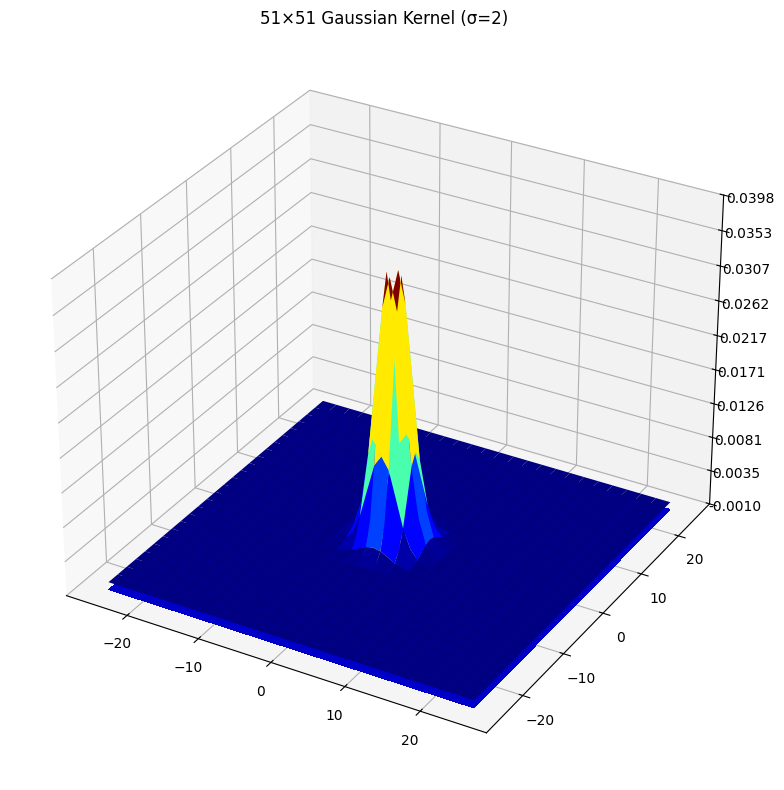

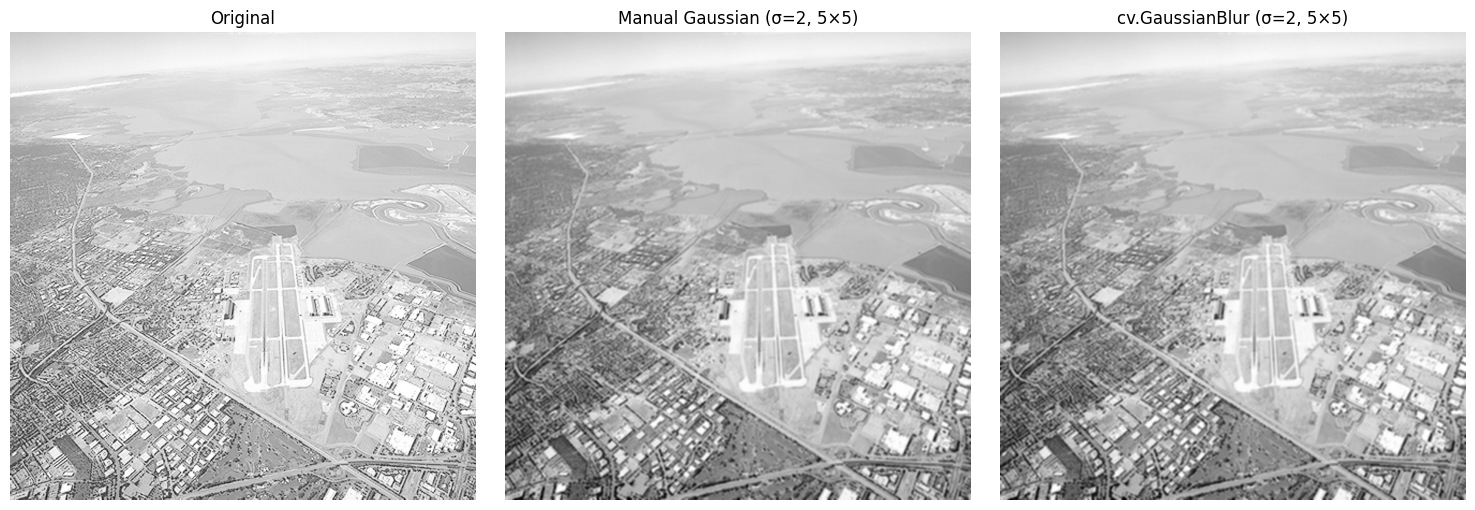

Max pixel difference (manual vs cv.GaussianBlur): 1


In [10]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter

#(a) Compute normalized 5×5 Gaussian kernel, σ = 2 
def gaussian_kernel(size, sigma):
    half = size // 2
    ax = np.arange(-half, half + 1)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return kernel / kernel.sum()  # normalize

sigma = 2
kernel_5x5 = gaussian_kernel(5, sigma)
print('5×5 Gaussian kernel (σ=2):')
print(np.round(kernel_5x5, 6))
print(f'Sum of kernel: {kernel_5x5.sum():.6f}')

#(b) Visualize 51×51 Gaussian kernel as 3D surface 
kernel_51x51 = gaussian_kernel(51, sigma)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
half = 51 // 2
X = np.arange(-half, half + 1)
Y = np.arange(-half, half + 1)
X, Y = np.meshgrid(X, Y)
surf = ax.plot_surface(X, Y, kernel_51x51, cmap=cm.jet, linewidth=0, antialiased=True)
ax.zaxis.set_major_locator(LinearLocator(10))
ax.zaxis.set_major_formatter(FormatStrFormatter('%.4f'))
cset = ax.contourf(X, Y, kernel_51x51, zdir='z',
                   offset=kernel_51x51.min() - 0.001, cmap=cm.jet)
ax.set_zlim(kernel_51x51.min() - 0.001, kernel_51x51.max())
ax.set_title(f'51×51 Gaussian Kernel (σ={sigma})')
plt.tight_layout()
plt.savefig('q5_gaussian_3d.png', dpi=150)
plt.show()

#(c) Apply Gaussian smoothing with manually computed kernel 
img = cv.imread('E:/ML/Images/Fig0309(a)(washed_out_aerial_image).tif', cv.IMREAD_GRAYSCALE)
assert img is not None

img_manual = cv.filter2D(img, cv.CV_32F, kernel_5x5.astype(np.float32))
img_manual_uint8 = np.clip(img_manual, 0, 255).astype('uint8')

#(d) Apply using cv.GaussianBlur()
img_cv_blur = cv.GaussianBlur(img, (5, 5), sigma)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(img_manual_uint8, cmap='gray')
axes[1].set_title('Manual Gaussian (σ=2, 5×5)')
axes[1].axis('off')
axes[2].imshow(img_cv_blur, cmap='gray')
axes[2].set_title('cv.GaussianBlur (σ=2, 5×5)')
axes[2].axis('off')
plt.tight_layout()
plt.savefig('q5_gaussian_filtering.png', dpi=150)
plt.show()

diff = np.abs(img_manual_uint8.astype(int) - img_cv_blur.astype(int))
print(f'Max pixel difference (manual vs cv.GaussianBlur): {diff.max()}')